# Introduction to PyTorch through an MNIST Variational Autoencoder (VAE)

**Half day · 4 hours**

* In this course, we'll learn about neural networks and PyTorch by working toward a small program that generates handwritten digits
  * You do not need prior PyTorch or deep learning experience
  * You should be comfortable reading Python functions and classes (but of course I'll help with anything that you find confusing)
  * You can work on your own machine, or upload this notebook to Google Colaboratory
* By the end of this course...
  * you'll understand what neural networks are and how they work
  * you'll be able to read and explain the main steps of a PyTorch training program–prepare data, build a model, measure its loss, and update its parameters
  * You'll have trained a small VAE and used it to generate new digit images
  * You'll know enough to keep experimenting with the notebook, even though 4 hours of course won't cover every PyTorch feature or the math behind VAEs

<a id="quicklinks"></a>
## Quick links to the exercises
* [Exercise 1](#Ex-1)
* [Exercise 2](#Ex-2)
* [Exercise 3](#Ex-3)
* [Exercise 4](#Ex-4)
* [Exercise 5](#Ex-5)
* [Exercise 6](#Ex-6)
* [Capstone](#Capstone)
* [Exercise 7](#Ex-7)
* [Hints/Reference answers](#Hints)

## Neural networks and other machine learning models

* In **traditional machine learning**, we usually choose measurements—called **features**—that may help with a task
  * For example, to predict rainfall, we might provide temperature, humidity, and air pressure
  * An algorithm uses examples to learn a relationship between those features and the outcome
  * Once trained, the model uses that relationship to predict an outcome for new data—such as a category in *classification* or a numerical value in *regression*
  * some popular ML agorithms include linear regression, decision trees, and random forests
* crucially, traditional models rely on experts to determine which features to pay attention to

* below is a pictorial representation of a spam classifier
![Messages entering a classifier and being sorted into inbox or spam](https://developers.google.com/static/machine-learning/guides/text-classification/images/TextClassificationExample.png)

*Image: [Google’s Text Classification guide](https://developers.google.com/machine-learning/guides/text-classification), CC BY 4.0.*

* A **neural network** is another kind of machine learning model, made of layers of adjustable calculations
  * Data passes through those layers to produce an output, and training changes the model’s parameters (called "weights" and "biases") to improve that output

* One difference is that neural networks can learn useful **intermediate representations** from the inputs
  * The VAE we will build starts with image pixels and learns its own short numerical descriptions of handwritten digits
  * We do not tell it which strokes or shapes to look for!

### "Deep Learning"
* uses neural networks with multiple layers
* as they run (train), those layers can learn useful patterns directly from the data (as such, neural nets are known as "representation ML models")

### Neurons
* an artificial neuron is a small calculation inside a neural network
* takes several input numbers, gives each one a learned weight, adds them together with a bias, and passes the result through an activation function (a rule which is applied to a neuron’s calculated value before passing it onward)
* **Note: Like an artificial neuron, a biological neuron receives signals from other neurons and can send a signal onward. Real neurons are much more complex, though, so a neural network is only loosely inspired by the brain.** 

* e.g., a neural network to *classify* digits 0..9
  
![MNIST digit classifier](https://image.slidesharecdn.com/cse802-lecture-180312204535/75/Introduction-to-Neural-Networks-and-Deep-Learning-22-2048.jpg)

*Source: [Introduction to Neural Networks and Deep Learning](https://www.slideshare.net/slideshow/introduction-to-neural-networks-and-deep-learning/90433728), slide 22.*

* But rather than a classifier, we will be building a neural network that learns from digit images and then generates new ones, something like this:
![A digit image passes through a VAE encoder, latent sample, and decoder](https://miro.medium.com/1%2Aohh8pBpSsMl3LmN0USxrLg.png)
* Source: [Variational Autoencoder with PyTorch](https://medium.com/dataseries/variational-autoencoder-with-pytorch-2d359cbf027b), Eugenia Anello

### Finally...
* Neural networks are not automatically the best choice!
* Simpler models can be faster to train and easier to interpret
* We’re using a small neural network here to explore PyTorch’s central ideas: layers, loss, gradients, and training

## Setup

* Run this cell once to installs any missing packages into your current notebook kernel
* A fresh installation may ask you to restart the kernel; if so, restart and run the notebook from the top
* The MNIST download in the next section requires internet access on its first run
* (On a machine with PyTorch already installed, the cell makes no changes)
* CPU training works; an Apple Silicon MPS device or CUDA GPU is optional

In [4]:
# These standard-library modules let us check for and install packages
import importlib.util
import subprocess
import sys

# Check which required packages are missing from this notebook's
# Python environment
missing = [
    name for name in ('torch', 'torchvision', 'matplotlib')
        if importlib.util.find_spec(name) is None
]

if missing:
    print('Installing:', ', '.join(missing))

    # sys.executable is the Python interpreter running this notebook
    # Using it ensures pip installs into the same environment
    # check_call() raises an error if installation fails
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', *missing]
    )

    # The kernel may need a restart to recognize newly installed packages
    print('If imports below fail, restart the kernel and run from the top.')
else:
    # No installation is needed when all packages are already present
    print('Required packages are already installed.')

Required packages are already installed.


In [5]:
# Python tools for repeatable random choices and file paths
import random
from pathlib import Path # lets us work with files/paths, mac and windows
import matplotlib.pyplot as plt # plotting package
import torch # PyTorch tensors and core operations
from torch import nn # Layers and model classes

# Functions such as the reconstruction loss
from torch.nn import functional as F

# Load training images in batches and select a smaller training set
from torch.utils.data import DataLoader, Subset

# Access MNIST and convert its images to tensors
from torchvision import datasets, transforms

# Use the same random seed so runs are easier to compare
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

# Use the CPU for broad compatibility
# Change to 'mps' or 'cuda' if the machine supports it
device = torch.device('cpu')

print('PyTorch:', torch.__version__, '| device:', device)

PyTorch: 2.14.0 | device: cpu


In [6]:
# check to see if CUDA or MPS (Metal Performance Shaders) is available

if torch.cuda.is_available(): # Linux/Windows...NVIDIA GPU available?
    device = torch.device('cuda')
elif torch.backends.mps.is_available(): # Mac...MPS available?
    device = torch.device('mps')
else:
    device = torch.device('cpu') # nope, stick with CPU

print('Using device:', device)

Using device: mps


## Some important terminology

**PyTorch** = PyTorch is a Python library that helps us create machine learning models–programs that learn from examples. It gives us tools to work with data, build those programs, and improve them through practice.

**Machine learning** = a subset of AI that uses algorithms to find patterns in data and make predictions without hard-coded rules

**Neural network** = a model made of layers of simple calculations
 * Each layer transforms its input, and the network learns by adjusting numbers called **weights** and **biases** (it does not work like a biological brain in any literal sense)

**Variational autoencoder (VAE)** = a particular kind of model built from neural networks. It usually has two parts:
- An encoder turns an input, such as an image, into a description of a small range of possible values
- A decoder turns a value sampled from that range back into an output

**Model** = the network’s structure together with its adjustable *parameters*. Before training, those parameters have starting values; after training, they hold values learned from data. ("Medical resident")

**Training** = the repeated process of showing the model examples, measuring its output with a *loss function*, and adjusting its parameters to reduce that loss. ("Medical residency")

**Loss function** = a way to measures how “off” a model’s predictions/outputs are (training aims to reduce this value, as we can see above)

**Gradient** = a number that tells us how changing a particular parameter would change the loss (error). The optimizer uses gradients to decide how to adjust the model’s weights and biases.

**Tensor** = PyTorch’s array-like container for numbers. Images, batches, model parameters, and predictions are all represented with tensors. We will inspect actual tensors in Section 2.

**NOTE:** You only need the gist of these definitions now. We will revisit each term alongside the code that uses it.

# What are we going to be building?
* MNIST is a database containing 28 × 28 grayscale images of handwritten digits (https://en.wikipedia.org/wiki/MNIST_database)
* Our task is **generation**–produce plausible new images. For now, picture these three steps:

  1. The **encoder** looks at a digit image and turns it into a short description made of numbers
  2. We pick a set of numbers based on that description
  3. The **decoder** uses those numbers to make a digit image

* A basic autoencoder learns to turn an image into a short description and then use that description to recreate the image
* vs. a variational autoencoder (VAE) learns to organize those descriptions so we can choose one without starting with an image. The decoder can then turn it into a new digit.

**Discuss:** A reconstruction starts with an MNIST image. Where does the decoder's input come from when generating a new digit? We will answer with code near the end.

# Tensors
* PyTorch’s way of storing numbers
   * a tensor can hold a single number, a list of numbers, a table, or a collection of tables
   * PyTorch uses tensors to represent data, model outputs, and the numbers the model learns during training

* a single number is a zero-dimensional tensor
* a sequence of numbers is one-dimensional, and a table is two-dimensional
* images and batches add more dimensions

* Tensors have
  * **shape** (size along each dimension)
  * **dtype** (type of number)
  * **device** (CPU, GPU, or MPS)

* Many operations resemble NumPy operations (if you're not familiar with NumPy don't worry)
* PyTorch tensors can also participate in automatic differentiation (how PyTorch calculates gradients for us) and we'll see this later

In [10]:
numbers = torch.tensor([2.0, 4.0, 6.0])
print('values:', numbers)
print('shape:', numbers.shape)
print('dtype:', numbers.dtype)
print('mean:', numbers.mean().item())

values: tensor([2., 4., 6.])
shape: torch.Size([3])
dtype: torch.float32
mean: 4.0


In [11]:
image_like = torch.arange(12).reshape(3, 4)
image_like

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [12]:
print('table shape:', image_like.shape)
print('first row:', image_like[0])

table shape: torch.Size([3, 4])
first row: tensor([0, 1, 2, 3])


<a id="Ex-1"><a/>
## Exercise 1: Read a tensor
[Click here to go back to list of Exercises](#quicklinks)

* Create a floating-point tensor containing __`[1, 3, 5, 7]`__
* Print its shape and the sum of its values
* Then change the code to select the final two values

**Check your work:**
* the shape is __`torch.Size([4])`__
* the sum is __`16.0`__
* the final two values are __`[5., 7.]`__


In [ ]:
# Exercise 1

# MNIST images

* __`ToTensor()`__ loads each image as a float tensor with pixel values from 0 to 1
* One image has shape __`[1, 28, 28]`__: one grayscale channel, 28 rows, 28 columns
* A batch adds a leading dimension: __`[batch_size, 1, 28, 28]`__.
* MNIST includes a label for each image, but our VAE trains on the images and ignores the labels

images: 60000
single image: torch.Size([1, 28, 28]) torch.float32
pixel range: 0.0 to 1.0
label (for inspection only): 5


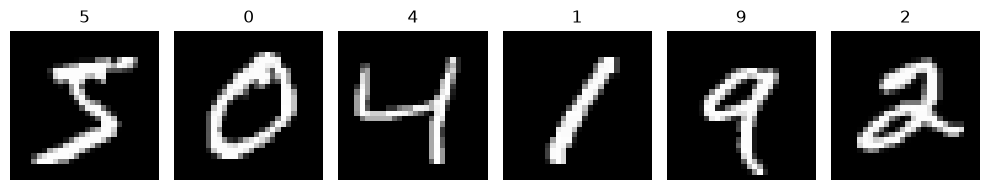

In [7]:
# Store the downloaded MNIST data in this folder
DATA_DIR = Path('mnist_data')

# Load the training images and labels. ToTensor() converts each image
# to a tensor with pixel values between 0 and 1.
mnist = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

# Inspect the first image and its label. The VAE will use the image,
# but the label is here only to help us understand the dataset.
image, label = mnist[0]
print('images:', len(mnist))
print('single image:', image.shape, image.dtype)
print('pixel range:', float(image.min()), 'to', float(image.max()))
print('label (for inspection only):', label)

# Create a row of six plots to see some examples.
fig, axes = plt.subplots(1, 6, figsize=(10, 2))

for ax, index in zip(axes, range(6)):
    img, digit = mnist[index]

    # Remove the one-channel dimension so imshow() receives a 28 × 28 grid.
    ax.imshow(img.squeeze(0), cmap='gray', vmin=0, vmax=1)
    ax.set_title(str(digit))
    ax.axis('off')

plt.tight_layout()
plt.show()

<a id="Ex-2"><a/>
## Exercise 2: Preserve the shape
[Click here to go back to list of Exercises](#quicklinks)
* The VAE will use a simple fully connected network
* Each image must become a vector of **784** pixel values
* Flatten a batch, then reshape its first vector back into a 28 × 28 image
* The check cell tells you whether both transformations preserved the data

In [9]:
# Load eight images at a time. shuffle=False keeps them in dataset order
# so the preview is predictable each time we run this cell.
preview_loader = DataLoader(mnist, batch_size=8, shuffle=False)

# Get the first batch: eight images and their corresponding digit labels.
# preview_images has shape [8, 1, 28, 28].
preview_images, preview_labels = next(iter(preview_loader))

# Exercise 2: Turn each 28 × 28 image into a row of 784 pixel values.
# The result should have shape [8, 784]: one row per image.
flat_preview = None  # TODO: reshape or flatten preview_images
flat_preview = preview_images.flatten(start_dim=1)
# Take the first flattened image and restore its 28 × 28 shape.
restored = None  # TODO: reshape flat_preview[0] into [28, 28]
restored = flat_preview[0].reshape(28, 28)

In [10]:
if flat_preview is not None:
    # Check that all eight images were flattened as expected.
    assert flat_preview.shape == (8, 784)

    # After creating restored, check its shape and verify that
    # it contains exactly the same pixel values as the original image.
    assert restored.shape == (28, 28)
    assert torch.equal(restored, preview_images[0, 0])

    print('Flattened shape:', flat_preview.shape)

Flattened shape: torch.Size([8, 784])


# Prepare images for training

* a **Dataset** represents examples that can be retrieved by index
* a **DataLoader** groups them into mini-batches and can shuffle their order
* an **epoch** is one pass through the selected training images
* we're going to use a subset to keep class time manageable, since this represents a lot of computation
* a batch size of 128 means the loader returns up to 128 images at once
  * the final batch may be smaller, so we read its actual size rather than assume 128

In [43]:
# Use 12,000 of MNIST's training images to keep this exercise manageable
TRAIN_SAMPLES = 60_000

# Select images at positions 0 through 11,999 in the dataset.
# A Subset still returns each image together with its digit label.
train_subset = Subset(mnist, range(TRAIN_SAMPLES))

# Ask the DataLoader for batches of up to 128 image-label pairs.
# shuffle=True changes their order when we iterate over the loader.
demo_loader = DataLoader(train_subset, batch_size=128, shuffle=True)

# Get one batch. The underscore tells Python to discard the labels as we
# receive them.
demo_images, _ = next(iter(demo_loader))

# The batch contains 128 images, each with one channel and 28 × 28 pixels.
print('batch:', demo_images.shape)  # [128, 1, 28, 28]

# Flatten each image into 784 values while keeping the batch dimension.
# start_dim=1 leaves dimension 0 (the 128 images) intact.
print('flattened batch:', demo_images.flatten(start_dim=1).shape) 

batch: torch.Size([128, 1, 28, 28])
flattened batch: torch.Size([128, 784])


<a id="Ex-3"><a/>
## Exercise 3: Make the training loader
[Click here to go back to list of Exercises](#quicklinks)

1. Create a shuffled __`DataLoader`__ named __`train_loader`__ using __`train_subset`__ and a batch size of 128
2. Retrieve one batch and confirm the image shape.

**Why shuffle?** The model should see the examples in a different order as it trains.


In [44]:
# Exercise 3 — replace None below
train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)

if train_loader is not None:
    images, labels = next(iter(train_loader))
    assert images.ndim == 4 and images.shape[1:] == (1, 28, 28)
    assert images.shape[0] <= 128
    print('One batch:', images.shape, '| batches per epoch:', len(train_loader))

One batch: torch.Size([128, 1, 28, 28]) | batches per epoch: 469


# Build the VAE

* Our VAE has two parts:
  * The **encoder** turns an image into a short description made of numbers
  * The **decoder** uses those numbers to produce an image
* We will build both parts using PyTorch layers

* An __`nn.Module`__ is PyTorch’s base class (data type) for a model or a piece of one
* We use __`nn.Linear`__ layers, which combine input values using adjustable **weights and biases**
* Training changes those values
* The __`forward()`__ method describes what happens when we give the model an image.

### From an image to a sample
* Each image has 28 × 28 pixels, or **784 values** when flattened
* The encoder processes those values and produces two short lists of numbers:
  * __`mu`__ describes the center of a range of possible descriptions for this image
  * __`logvar`__ helps describe how spread out that range is (stored in log variance form)

* Instead of giving the decoder one fixed description of each image, we choose a slightly different description from a learned range each time. This helps the decoder learn to turn points in that range into plausible images.
* (Remember that we want the decoder to learn to handle a region of possible descriptions, not just one fixed point per training image. That helps make it possible to draw a new point later, without supplying an image, and have the decoder produce a plausible digit.)
* This is why the model is *variational*: it works with a range of possibilities for each image

* The code for sampling is __`z = mu + exp(0.5 * logvar) * eps`__, or mathematically speaking:
$$
z = \mu + e^{\,0.5\,\mathrm{logvar}}\,\varepsilon
$$

* For now, read it as: **start at the center, then add some randomly chosen variation** (the random values are in __`eps`__)
* Writing the calculation this way lets PyTorch track how __`mu`__ and __`logvar`__ affected the result, so training can adjust the encoder
* This technique–adding random variation in a way that still lets the model learn–is called the **reparameterization trick**

### From a sample back to an image
* The decoder takes __`z`__ and produces **784 numbers**, one for each pixel. These raw numbers are called **logits** ("logistic units"); they can be positive or negative and are not yet pixel brightness values.
* Applying __`sigmoid`__ converts each logit to a value between **0 and 1**, which we can display as a grayscale pixel. During training, we pass the logits directly to the reconstruction loss because that loss handles the sigmoid conversion internally.

### Follow the numbers through the VAE

**Encoder:** 784 pixel values → 128 intermediate values → two __`mu`__ values and two __`logvar`__ values

* We use __`mu`__ and __`logvar`__ to randomly choose __`z`__, a two-number description that we pass to the decoder

**Decoder:** 2 numbers in __`z`__ → 128 intermediate values → 784 raw pixel outputs

* The model learns what the intermediate values represent; we do not define them ourselves

In [49]:
# Hyperparameters = settings we choose before training, rather than
# values our model learns from the data
#
# Represent each image using two numbers in the VAE's latent space.
# Chosen largely for teaching–each image gets a description with just
# two numbers, which we can later plot as a point on a 2D map.
# It limits how much detail the VAE can represent.
LATENT_DIM = 2

# A reasonable starting size for this small MNIST model. It gives the
# encoder and decoder room to learn while keeping training manageable.
HIDDEN_DIM = 256


class VAE(nn.Module): # nn.Module = PyTorch class we inherit from
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()

        # Run these encoder layers in order
        self.encoder = nn.Sequential(
            # Combine the image's 784 pixel values into hidden_dim
            # values, using weights and biases
            nn.Linear(784, hidden_dim),

            # Set negative values to zero, allowing the network to learn
            # more complex patterns...ReLU = "Rectified Linear Unit" and
            # the function is f(x) = max(0, x)
            nn.ReLU(),
        )

        # Turn the encoder's output into the center of this image's
        # possible descriptions
        self.to_mu = nn.Linear(hidden_dim, latent_dim)

        # Produce values that describe the spread of that range
        self.to_logvar = nn.Linear(hidden_dim, latent_dim)

        # Run these decoder layers in order
        self.decoder = nn.Sequential(
            # Expand the short latent description to hidden_dim values
            nn.Linear(latent_dim, hidden_dim),

            # Set negative values to zero, too ("add nonlinearity")
            nn.ReLU(),

            # Produce one raw output, or logit, for each of the 784 pixels.
            nn.Linear(hidden_dim, 784),
        )

        
    # Choose a slightly different set of numbers from the encoder's suggested
    # range (a "latent sample" using the center and spread from the encoder)
    def reparameterize(self, mu, logvar):
        # Exercise 4: replace this placeholder with a sample
        # whose shape is [batch_size, latent_dim] (see below)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        
        return mu + std * eps
        raise NotImplementedError('Complete the reparameterization exercise')

    
    # Describe what happens when we pass a batch of images to the model
    # or...how does an input become an output?
    def forward(self, images):
        # Change each [1, 28, 28] image into 784 values
        # Keep the batch dimension, giving us [batch_size, 784]
        flat = images.flatten(start_dim=1)

        # Pass the flattened images through the shared encoder layers
        hidden = self.encoder(flat)

        # Calculate a center and spread for each image's latent range
        mu = self.to_mu(hidden) # mean
        logvar = self.to_logvar(hidden) # spread

        # Draw one latent description per image
        z = self.reparameterize(mu, logvar)

        # Turn those descriptions into raw outputs for 784 pixels each
        reconstruction_logits = self.decoder(z)

        # Return the raw image outputs and the values needed to calculate loss.
        return reconstruction_logits, mu, logvar


# Create the VAE and move its parameters to the selected device
model = VAE().to(device)

# Count all learnable numbers (weights and biases) in the model.
print('Learnable parameters:', sum(p.numel() for p in model.parameters()))

Learnable parameters: 404244


* By inheriting from __`nn.Module`__, our VAE gets much of the PyTorch machinery a trainable model needs, e.g.,
  * tracking its layers and parameters
  * moving them to a device
  * running __`forward()`__ when we call __`model(images)`__
* We still define the model’s layers and how data moves through them
* __`nn.Module`__ handles the common bookkeeping around that code.

<a id="Ex-4"><a/>
## Exercise 4: Complete the model
[Click here to go back to list of Exercises](#quicklinks)

Edit __`reparameterize()`__ in the class above:

1. Compute __`std = torch.exp(0.5 * logvar)`__
2. Create noise with __`eps = torch.randn_like(std)`__
3. Return __`mu + std * eps`__

Rerun the class cell, then run the shape check below. __`randn_like`__ creates noise on the same device as __`std`__.

Input: torch.Size([128, 1, 28, 28])
Reconstruction logits: torch.Size([128, 784])
Mean and log variance: torch.Size([128, 2])


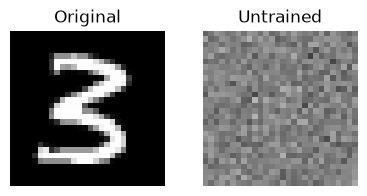

In [50]:
# This preview needs the DataLoader created in Exercise 3.
if train_loader is None:
    print('Complete Exercise 3 first.')
else:
    # Get one batch of images and labels; we do not need the labels.
    sample_images, _ = next(iter(train_loader))

    # Put this batch on the same device as the model (e.g., gpu, mps, cpu)
    sample_images = sample_images.to(device)

    try:
        # Run the batch through the VAE.
        # The model returns raw pixel outputs, mu, and logvar.
        sample_logits, sample_mu, sample_logvar = model(sample_images)

        # Each image should have 784 output logits: one per pixel.
        assert sample_logits.shape == (sample_images.shape[0], 784)

        # Each image should have LATENT_DIM mu values and logvar values.
        assert sample_mu.shape == sample_logvar.shape == (
            sample_images.shape[0], LATENT_DIM
        )

        # Print the shapes to see how the batch moves through the model.
        print('Input:', sample_images.shape)
        print('Reconstruction logits:', sample_logits.shape)
        print('Mean and log variance:', sample_mu.shape)

        # Make two plots: the original image and the model's output.
        fig, axes = plt.subplots(1, 2, figsize=(4, 2))

        # Show the first image's only grayscale channel.
        # Matplotlib needs the image on the CPU.
        axes[0].imshow(
            sample_images[0, 0].cpu(), cmap='gray', vmin=0, vmax=1
        )
        axes[0].set_title('Original')

        # Convert the first image's logits to values between 0 and 1,
        # reshape the 784 values into a 28 × 28 image, and move it to the CPU.
        untrained_image = (
            torch.sigmoid(sample_logits[0])
            .reshape(28, 28)
            .detach()
            .cpu()
        )
        axes[1].imshow(untrained_image, cmap='gray', vmin=0, vmax=1)
        axes[1].set_title('Untrained')

        # Hide tick marks and spacing around the two images.
        for ax in axes:
            ax.axis('off')

        plt.tight_layout()
        plt.show()

    # Until Exercise 4 is complete, reparameterize() raises this error.
    except NotImplementedError as exc:
        print(exc)

# Loss, gradients, and an update

* A **loss** is a number we want to reduce
* A VAE uses two parts:

  1. **Reconstruction loss** Essentially asks “How closely does the decoder’s image match the original?” The decoder produces one raw number for each pixel. Our loss function compares those numbers with the original image’s pixel values, which are between 0 and 1. It handles the conversion from raw numbers to the 0–1 range for us. (In PyTorch, this loss function is called binary cross-entropy with logits. Despite “binary” in its name, it can use our pixel values between 0 and 1; the images do not have to contain only black and white pixels.)

  3. **KL (Kullback–Leibler) divergence** is a second part of the loss and  asks a different question–“How different is the encoder’s proposed range of descriptions from a standard normal distribution?”
      * For each image, the encoder produces __`mu`__ and __`logvar`__ for each latent dimension
      * This calculation compares those values with a standard normal distribution, whose mean is 0 and variance is 1:
        - If __`mu`__ is near 0 and the variance is near 1, the KL value is near 0
        - Moving the center farther from 0, or making the range much narrower or wider, increases the KL value

* For each image, we add up the reconstruction error across its pixels and the KL contribution across its latent dimensions
  * We then average each total across the images in the batch
  * This keeps the two parts of the loss on the scales we intend; averaging reconstruction error over all 784 pixels instead would make it much smaller relative to KL divergence

* You do **not** need to derive the KL formula today–read the function as a supplied implementation of the two ideas above

In [51]:
def vae_loss(reconstruction_logits, images, mu, logvar):
    # Flatten each original image to match the decoder's 784 outputs
    # Keep the batch dimension: [batch_size, 1, 28, 28] → [batch_size, 784]
    flat_images = images.flatten(start_dim=1)

    # We divide by the actual number of images, since the last batch
    # may contain fewer images than the requested batch size.
    batch_size = images.shape[0]

    # Measure how well the decoder's raw outputs match the original pixels.
    # This function handles the sigmoid conversion internally.
    # Sum over all pixels and images, then average per image.
    reconstruction = F.binary_cross_entropy_with_logits(
        reconstruction_logits, flat_images, reduction='sum'
    ) / batch_size

    # Measure how far the encoder's proposed distribution for each image
    # is from a standard normal distribution (mean 0, variance 1).
    # exp(logvar) converts log variance back to variance.
    # Sum over both latent dimensions and all images, then average per image.
    kl = -0.5 * torch.sum(
        1 + logvar - mu.square() - logvar.exp()
    ) / batch_size

    # Training tries to reduce both parts of the loss.
    total = reconstruction + kl

    # Return the total and its two parts so we can inspect them separately.
    return total, reconstruction, kl

print('The loss function is ready.')

The loss function is ready.


## How the model learns from the loss

* So far, we can give the VAE an image and calculate a **loss** that measures how far its output is from what we want
* But calculating the loss does not, by itself, improve the model...we still need to adjust its weights and biases

* PyTorch’s **autograd** (PyTorch’s automatic differentiation system) helps with that
* While the model runs, **autograd** keeps track of the calculations involving its learnable parameters
* When we call __`loss.backward()`__, it calculates a **gradient** for each parameter–how a small change to that parameter would affect the loss

* An **optimizer** uses those gradients to adjust the parameters
* One training update follows this sequence:
  1. Run the model on a batch of images
  2. Calculate the loss
  3. Clear gradients left over from the previous update with   __`optimizer.zero_grad()`__
  4. Calculate new gradients with __`loss.backward()`__
  5. Update the parameters with __`optimizer.step()`__

* PyTorch adds newly calculated gradients to any gradients already stored which can be useful when we deliberately combine several batches before an update (e.g., due to memory issues)
  * But here, we want one update per batch, so we clear the old gradients first
* We’ll now try this sequence on a single batch before repeating it in a training loop

<a id="Ex-5"><a/>
## Exercise 5: Make one update
[Click here to go back to list of Exercises](#quicklinks)
* Complete the three TODO lines below
* Print the two loss components and the size of one parameter gradient
* A gradient is a direction for an update, not a score for how accurate the model is

In [52]:
# Adam is a commonly used optimizer that uses gradients to update the
# model’s weights and biases. The learning rate, lr, helps control the
# size of those updates.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Later cells need the training loader created in Exercise 3.
if train_loader is None:
    print('Complete Exercise 3 first.')
else:
    # Get one batch of images and labels. We don't need the labels.
    one_batch, _ = next(iter(train_loader))

    # Put the images on the same device as the model.
    one_batch = one_batch.to(device)

    try:
        # Run the images through the VAE.
        # It returns raw pixel outputs and the encoder's mu and logvar values.
        logits, mu, logvar = model(one_batch)

        # Measure the total loss and its two parts:
        # image reconstruction and KL divergence.
        loss, reconstruction, kl = vae_loss(logits, one_batch, mu, logvar)

        # Exercise 5: uncomment these lines and put them in the right order.
        # First clear old gradients, then calculate new ones,
        # then use them to update the model.
        # loss.backward()
        # optimizer.step()
        # optimizer.zero_grad()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # .item() converts each one-number tensor to a Python number for printing.
        print(f'total={loss.item():.1f}, reconstruction={reconstruction.item():.1f}, '
              f'KL={kl.item():.6f}')

        # Select one weight or bias tensor so we can inspect its gradient.
        first_parameter = next(model.parameters())

        # A gradient will be present after loss.backward() has run.
        if first_parameter.grad is not None:
            print('Mean absolute gradient:',
                  first_parameter.grad.abs().mean().item())
        else:
            print('No gradient yet — complete the TODO lines.')

    # Exercise 4 leaves a placeholder that raises this error until completed.
    except NotImplementedError as exc:
        print(exc)

total=550.5, reconstruction=550.5, KL=0.025479
Mean absolute gradient: 0.006825482472777367


# Assemble the training loop

* For each batch, we run the same five actions you just practiced
* Repeating them changes the parameters gradually
* We track the reconstruction and KL components separately so we can see what the model is doing

* __`model.train()`__ enables training behavior
* __`model.eval()`__ selects evaluation behavior
* Our VAE behaves the same in training and evaluation modes, but more complex models may behave differently (e.g., [dropout](https://towardsdatascience.com/dropout-in-neural-networks-47a162d621d9/) or [batch normalization](https://towardsdatascience.com/batch-norm-explained-visually-how-it-works-and-why-neural-networks-need-it-b18919692739/))
* We’ll use the appropriate mode now so the training code follows the same pattern we’d use with those models
* __`torch.no_grad()`__ avoids recording gradients when we only want to display or generate images

<a id="Ex-6"><a/>
## Exercise 6: Complete the loop
[Click here to go back to list of Exercises](#quicklinks)
* Fill in the five TODO lines below
* The function should return average total, reconstruction, and KL losses for one epoch
* Run the smoke test on **one batch** before the capstone

In [53]:
# Train the model for one pass through the loader.
# max_batches lets us stop early for a quick classroom run or smoke test.
def train_one_epoch(model, loader, optimizer, device, max_batches=None):
    model.train() # Set the model to training mode

    sums = torch.zeros(3) # Keep running totals for total loss, 
                          # reconstruction loss, and KL divergence
 
    count = 0 # Count how many images contributed to those totals

    # The loader supplies one batch of images and labels at a time,
    # but we ignore the labels.
    for batch_index, (images, _) in enumerate(loader):

        # Stop after max_batches batches if a limit was supplied
        if max_batches is not None and batch_index >= max_batches:
            break
        
        images = images.to(device) # Put batch on same device as the model

        # Exercise 6 — complete these lines in the order from Exercise 5:
        # logits, mu, logvar = ...
        # loss, reconstruction, kl = ...
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()
        # Then uncomment these two lines:
        # sums += torch.tensor([loss.item(), reconstruction.item(), kl.item()]) * images.shape[0]
        # count += images.shape[0]
        logits, mu, logvar = model(images)
        loss, reconstruction, kl = vae_loss(logits, images, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        sums += torch.tensor([loss.item(), reconstruction.item(), kl.item()]) * images.shape[0]
        count += images.shape[0]

    # If no images were counted, the exercise lines have not been completed
    if count == 0:
        raise RuntimeError('Complete the TODO lines before training.')

    # Convert the running totals to averages per image.
    # .tolist() returns three ordinary Python numbers.
    return (sums / count).tolist()


# Try the function on just one batch before training for full epochs.
if train_loader is not None:
    try:
        print('One-batch losses:', train_one_epoch(
            model, train_loader, optimizer, device, max_batches=1
        ))

    # Show an exercise-related error without stopping the rest of the notebook.
    except (NotImplementedError, RuntimeError) as exc:
        print(exc)

One-batch losses: [530.9298095703125, 530.811767578125, 0.11806337535381317]


<a id="Capstone"><a/>
# Capstone: train and generate digits
[Click here to go back to list of Exercises](#quicklinks)
* You now have all the parts
* The next cell trains on 12,000 MNIST images for four epochs
* It may take several minutes on a CPU
* If we are short on time, set __`EPOCHS = 2`__ and __`MAX_BATCHES_PER_EPOCH = 25`__; the notebook will still work, though generated digits will be rougher
* Rerunning the training cell continues training the current model

**Your goal:** show that training loss changes, compare inputs with reconstructions, then sample *new* latent vectors to generate a digit grid.

In [55]:
import time # so we can time the epochs

# Train for four passes through the selected training images.
EPOCHS = 4

# None uses every batch in each epoch.
# If need be, set this to 25 to make each shorter during a classroom demo.
MAX_BATCHES_PER_EPOCH = None

# Save the average losses from each epoch so we can plot them afterward.
# Rerunning this cell clears the previous history, but does not reset the model.
history = {'total': [], 'reconstruction': [], 'kl': []}

# Training requires the DataLoader created in Exercise 3.
if train_loader is None:
    print('Complete Exercise 3 first.')
else:
    try:
        start = time.time()
        # Repeat the training pass EPOCHS times.
        for epoch in range(EPOCHS):
            # Train for one epoch and get its three average losses.
            total, reconstruction, kl = train_one_epoch(
                model, train_loader, optimizer, device,
                max_batches=MAX_BATCHES_PER_EPOCH
            )

            # Add each loss to its corresponding list in history.
            for name, value in zip(history, (total, reconstruction, kl)):
                history[name].append(value)

            # Display this epoch's results.
            # Add 1 because Python counts from zero but we label epochs from one.
            print(
                f'Epoch {epoch + 1}/{EPOCHS}: '
                f'total={total:.1f}, '
                f'reconstruction={reconstruction:.1f}, '
                f'KL={kl:.1f}'
            )
        print(f'elapsed time: {time.time() - start:.1f} seconds')
    # Show an exercise-related error without stopping the notebook.
    except (NotImplementedError, RuntimeError) as exc:
        print('Complete Exercises 4 and 6:', exc)

Epoch 1/4: total=194.3, reconstruction=187.6, KL=6.7
Epoch 2/4: total=169.8, reconstruction=164.6, KL=5.2
Epoch 3/4: total=165.1, reconstruction=159.9, KL=5.3
Epoch 4/4: total=162.6, reconstruction=157.2, KL=5.4
elapsed time: 16.325622081756592


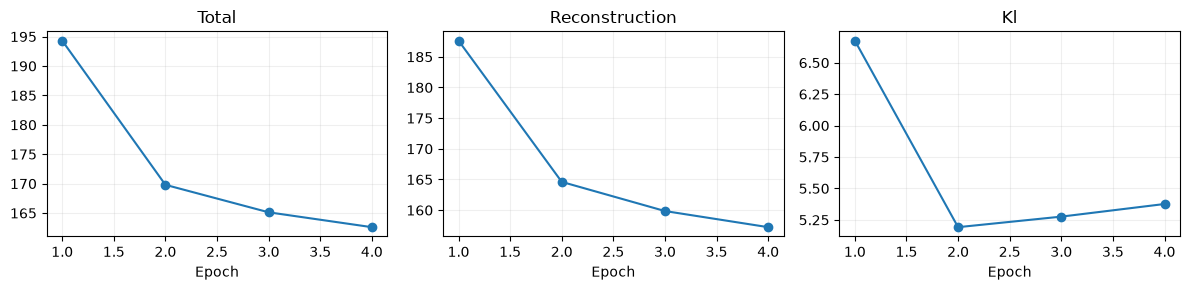

In [56]:
# Plot losses only if at least one epoch has finished.
if history['total']:
    # Create three plots in one row: total, reconstruction, and KL loss.
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))

    # Pair each plot with one list of loss values from history.
    for ax, (name, values) in zip(axes, history.items()):
        # Plot the loss against epoch numbers starting at 1.
        ax.plot(range(1, len(values) + 1), values, marker='o')

        # Label the plot with the name of the loss it shows.
        ax.set_title(name.capitalize())
        ax.set_xlabel('Epoch')

        # Add a faint grid to make the trend easier to read.
        ax.grid(alpha=0.2)

    # Adjust spacing so titles and labels don't crowd one another.
    plt.tight_layout()
    plt.show()
else:
    print('Run the training cell to plot loss.')

## Reconstructions: start with real images

The encoder reads an MNIST image and the decoder tries to reproduce it. We apply __`sigmoid`__ to the decoder's logits to display pixel values. These outputs are **reconstructions**, not new samples.

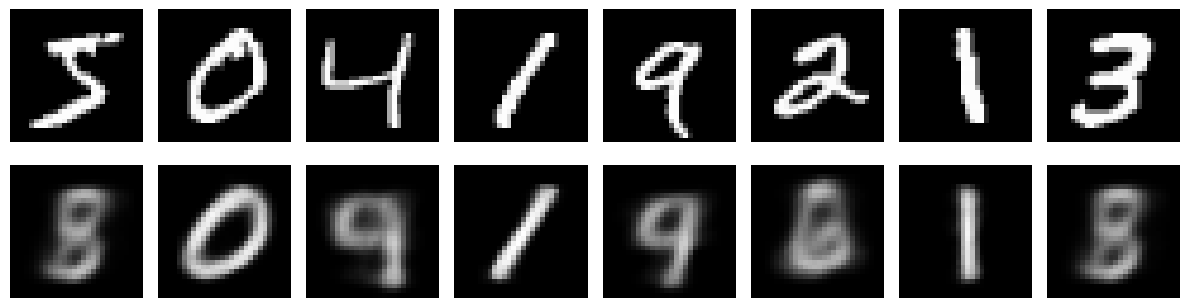

In [57]:
# Show reconstructions only after training has recorded at least one epoch.
if history['total']:
    # Put the model in evaluation mode.
    model.eval()

    # Get the same eight images used in our earlier preview.
    # We do not need their digit labels.
    original_images, _ = next(iter(preview_loader))

    # We are displaying results, not calculating gradients or updating weights.
    with torch.no_grad():
        # Move the images to the model's device and run them through the VAE.
        # We need the decoder's logits, but not mu or logvar here.
        logits, _, _ = model(original_images.to(device))

        # Convert raw logits to 0–1 pixel values, reshape them into images,
        # and move them to the CPU so Matplotlib can display them.
        reconstructed = torch.sigmoid(logits).reshape(-1, 28, 28).cpu()

    # Make two rows of eight images:
    # originals on top and their reconstructions underneath.
    fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))

    for i in range(8):
        # Select the only grayscale channel of the original image.
        axes[0, i].imshow(
            original_images[i, 0], cmap='gray', vmin=0, vmax=1
        )

        # Show the corresponding image produced by the VAE.
        axes[1, i].imshow(
            reconstructed[i], cmap='gray', vmin=0, vmax=1
        )

        # Hide ticks and borders around both images.
        for ax in (axes[0, i], axes[1, i]):
            ax.axis('off')

    # Label the two rows.
    axes[0, 0].set_ylabel('Original')
    axes[1, 0].set_ylabel('Reconstruction')

    plt.tight_layout()
    plt.show()
else:
    print('Train the model first.')

### Visualize the VAE’s learned latent space

* Our VAE describes each image using two latent values, so we can plot those values as a point
* For each MNIST image, we’ll use the encoder’s two __`mu`__ values as its coordinates
* We’ll color the points by their MNIST labels **only to help us interpret the plot**
* The VAE did not use those labels during training!
* Look for areas where similar digits gather and where different digits overlap

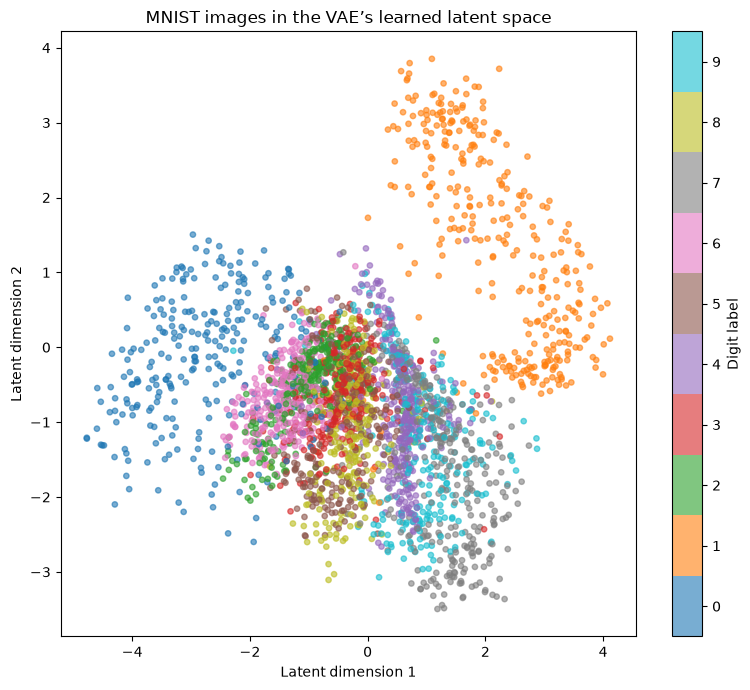

In [58]:
# Plot 3,000 images so the figure is useful without taking too long to make.
# Each batch will contain up to 256 images.
plot_loader = DataLoader(
    Subset(mnist, range(3_000)),
    batch_size=256,
    shuffle=False,
)

# Tell the model we are inspecting it rather than training it.
model.eval()

# Collect each image's two latent coordinates and its digit label.
points = []
digit_labels = []

# We don't need gradients because we aren't updating the model.
with torch.no_grad():
    for images, labels in plot_loader:
        # Put the images on the same device as the model.
        images = images.to(device)

        # Flatten each image from [1, 28, 28] to 784 pixel values.
        flat = images.flatten(start_dim=1)

        # Run those values through the encoder's shared layers.
        hidden = model.encoder(flat)

        # Get the two mu values for each image.
        # We'll use these as its x and y coordinates in the plot.
        mu = model.to_mu(hidden)

        # Move the coordinates back to the CPU for plotting.
        points.append(mu.cpu())

        # Keep the labels so we can color the dots afterward.
        # The VAE did not use these labels to learn the coordinates.
        digit_labels.append(labels)

# Join the batches into one array of coordinates and one array of labels.
points = torch.cat(points).numpy()
digit_labels = torch.cat(digit_labels).numpy()

# Draw one dot per image at its two learned coordinates.
plt.figure(figsize=(8, 7))
scatter = plt.scatter(
    points[:, 0], points[:, 1],
    c=digit_labels, cmap='tab10',
    vmin=-0.5, vmax=9.5,
    alpha=0.6, s=15,
)

# Show which color corresponds to each digit label.
plt.colorbar(scatter, label='Digit label', ticks=range(10))
plt.title('MNIST images in the VAE’s learned latent space')
plt.xlabel('Latent dimension 1')
plt.ylabel('Latent dimension 2')
plt.tight_layout()
plt.show()

<a id="Ex-7"></a>
## Exercise 7: Generate new digits
[Click here to go back to list of Exercises](#quicklinks)
* Unlike a reconstruction, generation starts with **no input image**
* Draw 16 latent vectors from a standard normal distribution using __`torch.randn(16, LATENT_DIM, device=device)`__
* Pass them directly to __`model.decoder`__, apply __`sigmoid`__, and reshape the result into 16 images
* Complete the TODOs and run the plot

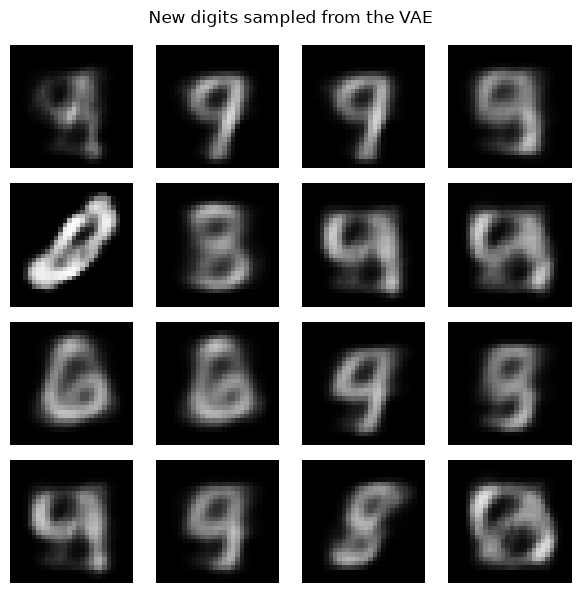

In [59]:
# Generate new digits only after the model has been trained
if history['total']:
    # Put the model in evaluation mode
    model.eval()

    # We are generating images, not training, so no gradients are needed
    with torch.no_grad(): # with starts a "context manager"...essentially
        # “While I’m doing this work, use this special setting—
        # and put things back afterward.”
        
        # The key is that entering the block temporarily turns off PyTorch’s
        # gradient tracking and leaving the block restores it
        
        # Exercise 7 — replace None.
        # Start with random two-number points; no MNIST images are used here.
        z = None  # TODO: draw 16 latent vectors on the chosen device
        generated_logits = None  # TODO: pass z to model.decoder
        generated = None         # TODO: sigmoid, reshape to [16, 28, 28], move to CPU
        z = torch.randn(16, LATENT_DIM, device=device)
        generated_logits = model.decoder(z)
        generated = torch.sigmoid(generated_logits).reshape(16, 28, 28).cpu()

    # Wait until the exercise has supplied latent vectors.
    if z is not None:
        # Arrange the 16 generated images in a 4 × 4 grid.
        fig, axes = plt.subplots(4, 4, figsize=(6, 6))

        # Pair each plotting area with one generated image.
        for ax, img in zip(axes.flat, generated):
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            ax.axis('off')

        plt.suptitle('New digits sampled from the VAE')
        plt.tight_layout()
        plt.show()
else:
    print('Train the model first.')

## Capstone reflection

Write short answers in this cell:

1. Where does the decoder input come from for a reconstruction? Where does it come from for a new sample?
2. What happened to reconstruction loss over your run? What happened to KL divergence?
3. Are all generated images recognizable digits? What might you change if they are blurry?
4. Change __`LATENT_DIM`__ **only by creating a new VAE and optimizer**; why would changing the constant alone break an existing model? If time is short, change __`EPOCHS`__ or the number of batches instead and compare the generated grid.

**Your answers:**

- 1.
- 2.
- 3.
- 4.


## Optional exploration: A map of generated digits

* Our latent space has two dimensions, so we can choose points across a grid and ask the decoder what image it makes at each point
* **Each small square is a new image generated by the VAE**—it does not correspond to a particular MNIST input image

* Read the grid as a map:
  * Moving **left to right** increases the first latent value from −2.5 to 2.5
  * Moving **top to bottom** increases the second latent value from −2.5 to 2.5
  * Neighboring squares come from nearby points in the latent space

* Start near the **center**, where points are more likely under the standard normal distribution used for generation
  * Then scan across a row and down a column
  * Notice whether a digit’s shape changes gradually, turns into a different digit, or becomes hard to recognize
  * Points near the edges are less likely to be chosen during ordinary random generation
* The axes are learned coordinates, **not named features** such as “roundness” or “stroke thickness
* We did not tell the VAE which digits to put in particular areas!

**Discuss:** Where do you see a smooth transition? Where do you see an ambiguous image? Does every point produce a recognizable digit?

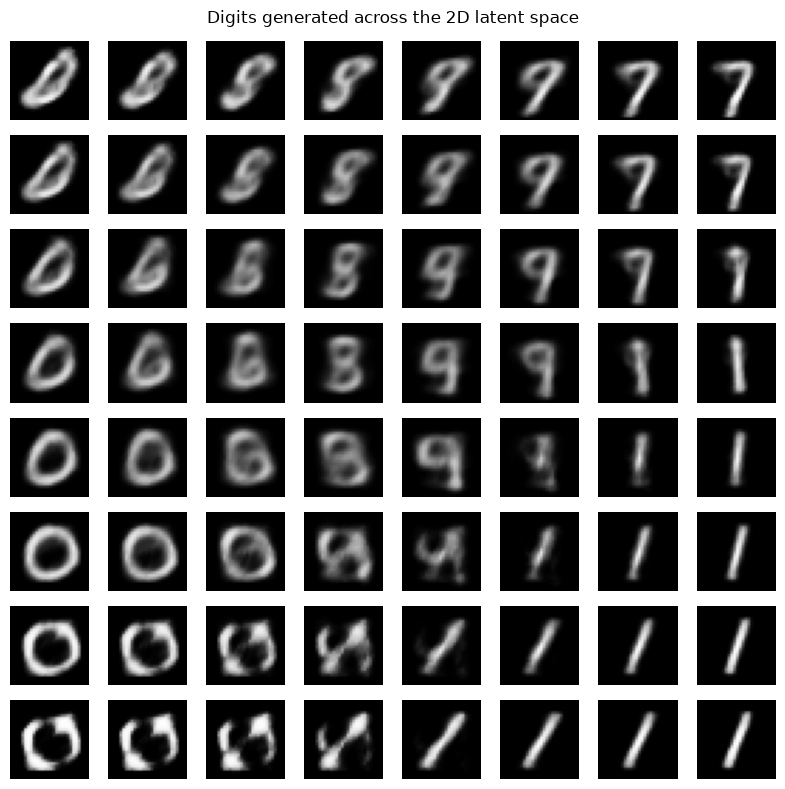

In [60]:
# Choose eight evenly spaced values from -2.5 to 2.5 for each
# of the VAE's two latent dimensions.
coordinates = torch.linspace(-2.5, 2.5, steps=8)

# Make an 8 × 8 grid of coordinate pairs.
# Across a row, x changes; down a column, y changes.
y_grid, x_grid = torch.meshgrid(coordinates, coordinates, indexing='ij')

# Turn the grid into 64 pairs of numbers, one pair for each image.
# Put them on the same device as the trained model.
z_grid = torch.stack(
    (x_grid.flatten(), y_grid.flatten()), dim=1
).to(device)

# Use the trained decoder to turn each pair into 784 raw pixel outputs.
# No MNIST image goes through the encoder in this exercise.
model.eval()
with torch.no_grad():
    logits = model.decoder(z_grid)

    # Convert the raw outputs to pixel values between 0 and 1.
    # Arrange the 64 results as [8 rows, 8 columns, 28, 28].
    # Move them to the CPU for Matplotlib.
    digit_grid = (
        torch.sigmoid(logits)
        .reshape(8, 8, 28, 28)
        .cpu()
    )

# Create 64 plotting areas in the same 8 × 8 arrangement.
fig, axes = plt.subplots(8, 8, figsize=(8, 8))

for row in range(8):
    for column in range(8):
        # Show the digit produced at this grid location.
        axes[row, column].imshow(
            digit_grid[row, column],
            cmap='gray',
            vmin=0,
            vmax=1,
        )

        # Hide axes so we can focus on changes between neighboring images.
        axes[row, column].axis('off')

plt.suptitle('Digits generated across the 2D latent space')
plt.tight_layout()
plt.show()

## Optional experiment: Continue training
* We will save a few images from the current model, train it for five more epochs, and generate the images again. The model and optimizer are **not recreated**: training continues from where the capstone ended
* We use the same input images and the same latent points for both views *
* Compare the results, then consider whether the improvement was worth the additional training time

Additional epoch 1/5: total loss=160.8
Additional epoch 2/5: total loss=159.4
Additional epoch 3/5: total loss=158.3
Additional epoch 4/5: total loss=157.5
Additional epoch 5/5: total loss=156.7


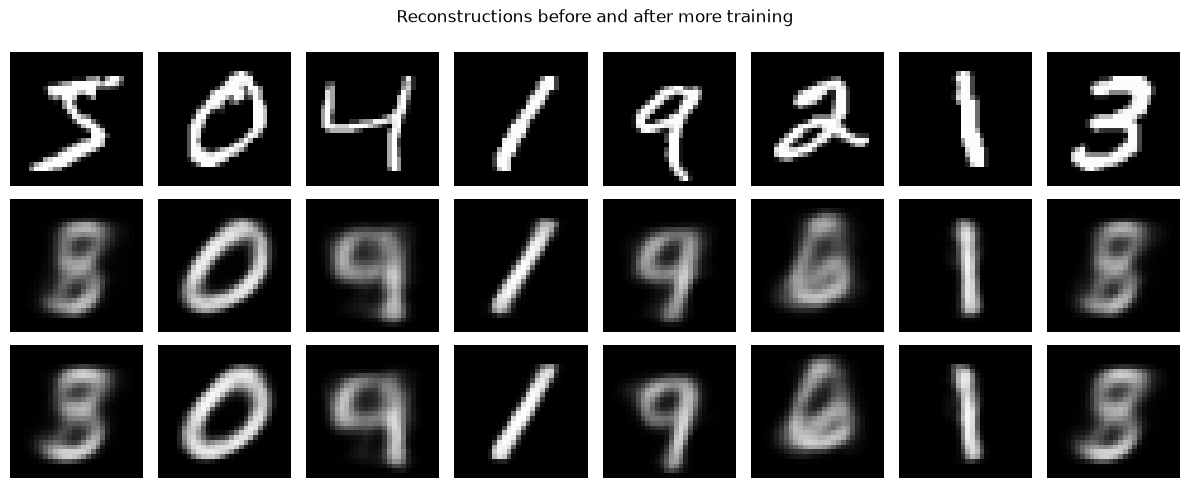

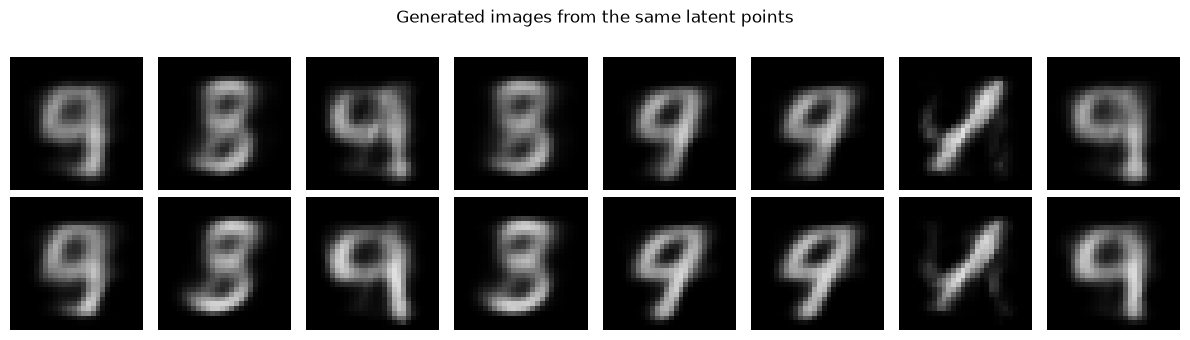

In [61]:
# Choose eight MNIST images to compare before and after more training.
# We save this batch so both views use the exact same originals.
comparison_images, _ = next(iter(preview_loader))
comparison_images = comparison_images.to(device)

# Also choose eight two-number points for generating new images.
# The seed makes these points reproducible. Drawing them on the CPU
# with a separate generator avoids changing the randomness used by training.
comparison_z = torch.randn(
    8, LATENT_DIM, generator=torch.Generator().manual_seed(123)
).to(device)


def make_comparison_images(model, images, z):
    """Make reconstructions and new images from the supplied inputs."""

    # Tell the model we are inspecting its output, not training it
    model.eval()

    # We do not need gradients while making images for display
    with torch.no_grad():
        # For each original image, the encoder produces a hidden result
        # and then a two-number center called mu
        hidden = model.encoder(images.flatten(start_dim=1))
        mu = model.to_mu(hidden)

        # Give each center directly to the decoder to reconstruct its image.
        # Usually the VAE samples a point near mu. Here we use mu itself
        # so random sampling cannot affect the before-and-after comparison.
        reconstructions = (
            torch.sigmoid(model.decoder(mu))  # Convert outputs to pixel values
            .reshape(-1, 28, 28)              # Restore the image shape
            .cpu()                            # Move results to CPU for plotting
        )

        # Generate new images from our eight saved points
        # These points did not come from MNIST images!
        generated = (
            torch.sigmoid(model.decoder(z))
            .reshape(-1, 28, 28)
            .cpu()
        )

    return reconstructions, generated


# Capture what the model produces before additional training.
before_reconstructions, before_generated = make_comparison_images(
    model, comparison_images, comparison_z
)

# Continue training this same model for five full passes through the
# training data. The optimizer also keeps its state from earlier training.
extra_history = []

for extra_epoch in range(5):
    losses = train_one_epoch(model, train_loader, optimizer, device)

    # Save all three losses in case we want to inspect them later.
    # losses contains: [total, reconstruction, KL].
    extra_history.append(losses)
    print(f'Additional epoch {extra_epoch + 1}/5: total loss={losses[0]:.1f}')

# Use the same originals and the same generated points after training.
after_reconstructions, after_generated = make_comparison_images(
    model, comparison_images, comparison_z
)

# First plot: each column follows one original MNIST image.
# The rows show the original, its reconstruction before, and its
# reconstruction after the five additional epochs.
fig, axes = plt.subplots(3, 8, figsize=(12, 5))

for i in range(8):
    axes[0, i].imshow(
        comparison_images[i, 0].cpu(), cmap='gray', vmin=0, vmax=1
    )
    axes[1, i].imshow(
        before_reconstructions[i], cmap='gray', vmin=0, vmax=1
    )
    axes[2, i].imshow(
        after_reconstructions[i], cmap='gray', vmin=0, vmax=1
    )

    # Hide tick marks and borders so we can focus on the digits.
    for row in range(3):
        axes[row, i].axis('off')

axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Before')
axes[2, 0].set_ylabel('After')
plt.suptitle('Reconstructions before and after more training')
plt.tight_layout()
plt.show()

# Second plot: each column uses one of our saved two-number points.
# Any difference between the rows comes from additional training,
# because we gave the decoder the same points both times.
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))

for i in range(8):
    axes[0, i].imshow(before_generated[i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(after_generated[i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Before')
axes[1, 0].set_ylabel('After')
plt.suptitle('Generated images from the same latent points')
plt.tight_layout()
plt.show()

## Optional experiment: Compare model widths
* Our original VAE uses 128 intermediate values in its encoder and decoder
  * Does increasing that number to 256 help?
* We'll train two fresh VAEs, one with each width
  * Both retain a two-dimensional latent space and train for the same number of epochs
* Compare their losses and the digits they generate.
* Note: A single run is an experiment, not proof that one width is always better
  * Training involves randomness, and a wider model also takes more computation


Training a model with hidden_dim=128
  Epoch 1: total=210.9
  Epoch 2: total=175.1
  Epoch 3: total=168.2
  Epoch 4: total=165.3

Training a model with hidden_dim=256
  Epoch 1: total=195.7
  Epoch 2: total=171.2
  Epoch 3: total=166.1
  Epoch 4: total=163.3


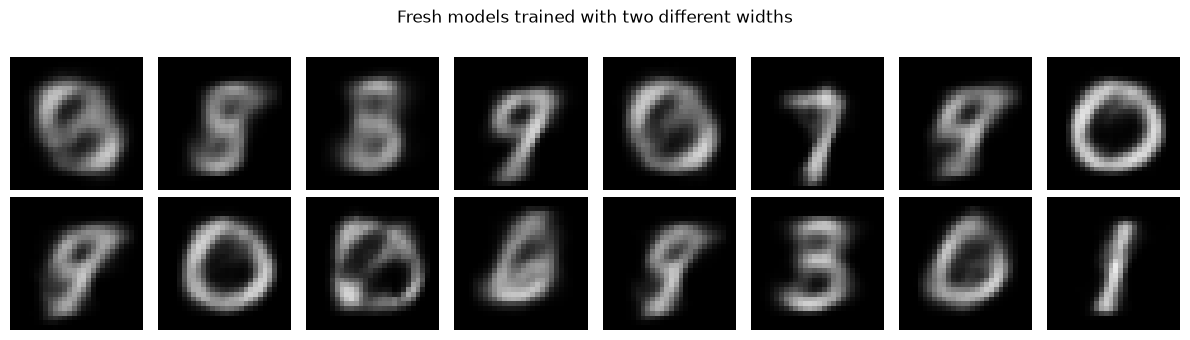

In [62]:
# Train each model for the same number of passes through the dataset
COMPARISON_EPOCHS = 4

# Store each trained model and its losses so we can compare them later
comparison_results = {}

# Try two sizes for the VAE's hidden layers: 128 and 256 numbers
for width in (128, 256):
    print(f'\nTraining a model with hidden_dim={width}')

    # Start with a new model for each width. Otherwise, the second model
    # would already have learned from the first model's training.
    # Reset the seed so the experiment is as repeatable as possible.
    torch.manual_seed(SEED)
    comparison_model = VAE(
        latent_dim=2,       # Keep the latent description at two numbers
        hidden_dim=width,   # Change only the hidden-layer width
    ).to(device)

    # Each model needs an optimizer connected to its own parameters
    comparison_optimizer = torch.optim.Adam(
        comparison_model.parameters(), lr=1e-3
    )

    # Both models see the training images in the same shuffled order
    # Using a separate generator keeps this shuffle sequence reproducible
    comparison_loader = DataLoader(
        train_subset,
        batch_size=128,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )

    # Record [total loss, reconstruction loss, KL loss] after each epoch
    losses_by_epoch = []

    for epoch in range(COMPARISON_EPOCHS):
        # Train for one complete pass through the selected MNIST images
        losses = train_one_epoch(
            comparison_model,
            comparison_loader,
            comparison_optimizer,
            device,
        )
        losses_by_epoch.append(losses)
        print(f'  Epoch {epoch + 1}: total={losses[0]:.1f}')

    # Save this model and its results under its width (128 or 256)
    comparison_results[width] = {
        'model': comparison_model,
        'losses': losses_by_epoch,
    }

# Choose eight fixed two-number points in latent space
# Both decoders receive these same points, so the input is held constant
fixed_z = torch.randn(
    8, 2, generator=torch.Generator().manual_seed(456)
).to(device)

# Make one row of generated images per model
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))

for row, width in enumerate((128, 256)):
    # Retrieve the model trained with this width.
    comparison_model = comparison_results[width]['model']
    comparison_model.eval()

    # Generate images for display without tracking gradients
    with torch.no_grad():
        images = (
            torch.sigmoid(comparison_model.decoder(fixed_z)) # Pixel values
            .reshape(8, 28, 28)                              # Eight images
            .cpu()                                           # for Matplotlib
        )

    # Put the eight generated images across this model's row
    for i in range(8):
        axes[row, i].imshow(images[i], cmap='gray', vmin=0, vmax=1)
        axes[row, i].axis('off')

    axes[row, 0].set_ylabel(f'Width {width}')

plt.suptitle('Fresh models trained with two different widths')
plt.tight_layout()
plt.show()

## Save your work!
Save the notebook itself to retain your exercise code and plots. After training, the optional cell below also saves the model parameters in a separate file; the notebook remains usable without that file, but training must be rerun to recreate the model.

## Wrap up

* The full PyTorch path is **tensors → model → loss → gradients → optimizer updates**
* The same path appears in many other PyTorch projects
* In this notebook, the decoder has two uses: reconstruct an encoded image and generate an image from a newly sampled latent vector
* The simple fully connected VAE is designed for learning
* A longer project could train for more epochs, change the network architecture, compare latent dimensions, or use a held-out MNIST test set to evaluate reconstructions

In [ ]:
# Optional: run this after training to save the model's learned weights
# and biases. You can load them later instead of training again.
# This saves the parameters, not the notebook or the training data.

# torch.save(model.state_dict(), 'mnist_vae_state.pt')

# Epilogue: Two ways to view the digit images

* Each MNIST image contains **784 pixel values**–too many dimensions to plot directly, so we use two methods to give each image a position on a two-dimensional scatterplot:

  * **PCA view:** (principal component analysis) PCA finds directions along which the images vary. The first principal component captures the most variation; the second captures the most variation remaining in a different direction. These directions are combinations of pixel values. They aren’t necessarily recognizable features such as “roundness” or “a vertical stroke.”
  * **t-SNE view:** (t-distributed stochastic neighbor embedding) a technique for making a two-dimensional picture of data that has many dimensions. We first keep 50 PCA components, then use t-SNE to arrange the images in two dimensions. t-SNE emphasizes which images are near one another.

Each dot is one image. Its color shows the digit label supplied by MNIST; **neither PCA nor t-SNE uses the labels to position the dots**.

Compare where colors overlap or form groups. In the PCA view, overlap means images have similar values on the *two components shown*; they may still differ in other ways. In the t-SNE view, nearby dots are useful for spotting similar images, but distances between faraway groups are harder to interpret.

These plots help us explore the original image data. IMPORTANT: **Neither plot shows the latent space learned by our VAE.**

Calculating principal components...
Calculating the t-SNE projection...


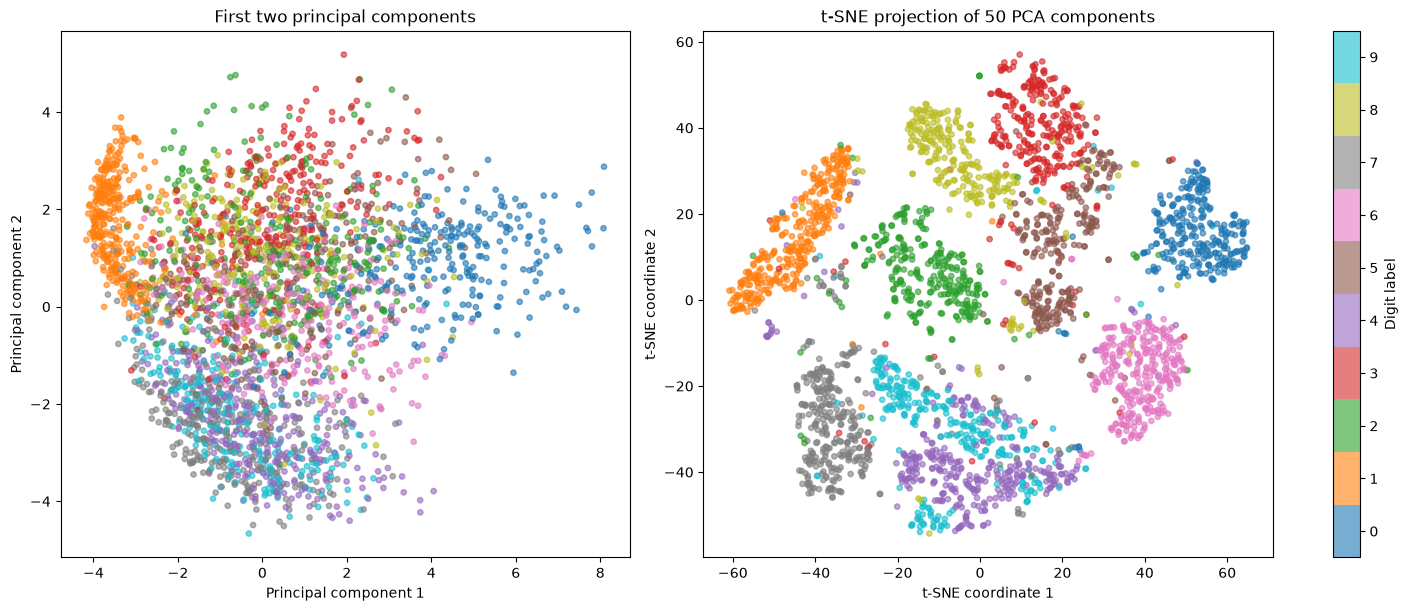

In [66]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Use up to 3,000 images to keep the visualization reasonably quick.
N_SAMPLES = min(3_000, len(mnist))

# In our notebook, mnist[index] returns (image, digit label).
# ToTensor() has already converted pixel values to the range [0, 1],
# so we do not divide them by 255 again.
pixel_rows = []
digit_labels = []

for index in range(N_SAMPLES):
    image, label = mnist[index]

    # Turn each [1, 28, 28] image into a row of 784 pixel values.
    pixel_rows.append(image.flatten().numpy())
    digit_labels.append(label)

# Make one array of images and another of their labels.
# X has shape [3000, 784]; y contains one digit label per image.
X = np.stack(pixel_rows)
y = np.asarray(digit_labels, dtype=int)

# Find 50 principal components.
# We will plot the first two directly and give all 50 to t-SNE.
print('Calculating principal components...')
X_pca = PCA(
    n_components=50,
    random_state=42,
).fit_transform(X)

# Create a separate two-dimensional view using t-SNE.
# This step may take a little while.
# The default iteration count is 1,000; omitting the argument also
# avoids the n_iter/max_iter naming difference between sklearn versions.
print('Calculating the t-SNE projection...')
X_2d = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
).fit_transform(X_pca)

# Compare the two views of the same images.
# Labels provide colors only; neither method uses them to place points.
fig, axes = plt.subplots(
    1, 2, figsize=(14, 6), constrained_layout=True
)

plots = [
    (
        X_pca[:, :2],
        'First two principal components',
        'Principal component 1',
        'Principal component 2',
    ),
    (
        X_2d,
        't-SNE projection of 50 PCA components',
        't-SNE coordinate 1',
        't-SNE coordinate 2',
    ),
]

for ax, (points, title, xlabel, ylabel) in zip(axes, plots):
    scatter = ax.scatter(
        points[:, 0], points[:, 1],
        c=y,
        cmap='tab10',
        vmin=-0.5,
        vmax=9.5,
        alpha=0.6,
        s=15,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# Both plots use the same colors for digit labels.
fig.colorbar(scatter, ax=axes, label='Digit label', ticks=range(10))
plt.show()

<a id="Hints"></a>
# Hints and reference answers
[Click here to go back to list of Exercises](#quicklinks)

Try each exercise first. Click its title for a hint. If you’re still stuck, click **Show me the code** inside the hint.

<details><summary>Discuss</summary>
<p><b>Q:</b> Where does the decoder's input come from?</p>
<p><b>A:</b> It comes from a randomly chosen two-number point in the VAE’s two-dimensional latent space.</p>   
</details>
<details><summary>Exercise 1 — Hint</summary>
<p>Create a <code>torch.float32</code> tensor. Use <code>.shape</code>, <code>.sum()</code>, and a slice starting at <code>-2</code>.</p>
<details><summary>Show me the code</summary>
<pre><code>values = torch.tensor([1, 3, 5, 7], dtype=torch.float32)
print('shape:', values.shape)
print('sum:', values.sum().item())
print('last two:', values[-2:])</code></pre>
</details>
</details>

<details><summary>Exercise 2 — Hint</summary>
<p>Flatten the image dimensions while keeping the batch dimension. Then reshape the first flattened image into a 28 × 28 grid.</p>
<details><summary>Show me the code</summary>
<pre><code>flat_preview = preview_images.flatten(start_dim=1)
restored = flat_preview[0].reshape(28, 28)</code></pre>
</details>
</details>

<details><summary>Exercise 3 — Hint</summary>
<p>Create a <code>DataLoader</code> from <code>train_subset</code>. Use batches of 128, enable shuffling, and name it <code>train_loader</code>.</p>
<details><summary>Show me the code</summary>
<pre><code>train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)</code></pre>
</details>
</details>

<details><summary>Exercise 4 — Hint</summary>
<p>Inside <code>reparameterize()</code>, convert <code>logvar</code> to a standard deviation. Draw noise with the same shape, scale it, and add it to <code>mu</code>. Rerun the class cell after editing it.</p>
<details><summary>Show me the code</summary>
<pre><code>std = torch.exp(0.5 * logvar)
eps = torch.randn_like(std)
return mu + std * eps</code></pre>
</details>
</details>

<details><summary>Exercise 5 — Hint</summary>
<p>After calculating the loss, clear old gradients, calculate new gradients, and update the parameters—in that order.</p>
<details><summary>Show me the code</summary>
<pre><code>optimizer.zero_grad()
loss.backward()
optimizer.step()</code></pre>
</details>
</details>

<details><summary>Exercise 6 — Hint</summary>
<p>For each batch, run the model, calculate the loss, and perform the three update steps from Exercise 5. When accumulating results, account for the actual number of images in the batch.</p>
<details><summary>Show me the code</summary>
<pre><code>logits, mu, logvar = model(images)
loss, reconstruction, kl = vae_loss(logits, images, mu, logvar)
optimizer.zero_grad()
loss.backward()
optimizer.step()
sums += torch.tensor([loss.item(), reconstruction.item(), kl.item()]) * images.shape[0]
count += images.shape[0]</code></pre>
</details>
</details>

<details><summary>Exercise 7 — Hint</summary>
<p>Draw 16 random points in latent space, pass them to the decoder, use <code>sigmoid</code> to obtain pixel values, and reshape them into images.</p>
<details><summary>Show me the code</summary>
<pre><code>z = torch.randn(16, LATENT_DIM, device=device)
generated_logits = model.decoder(z)
generated = torch.sigmoid(generated_logits).reshape(16, 28, 28).cpu()</code></pre>
</details>
</details>

<details><summary>Capstone reflection: reference answers</summary>
    
1. **Where does the decoder input come from?** For a reconstruction, the encoder processes an MNIST image and produces __`mu`__ and __`logvar`__. We use them to sample a two-number __`z`__, which goes to the decoder. For a new image, we start with no MNIST image: we randomly choose __`z`__ from a standard normal distribution and pass it directly to the decoder.

2. **What happened to the losses?** Reconstruction loss should generally decrease as the model learns to reproduce images. KL divergence may rise from a value near zero as the encoder begins giving different images more useful descriptions; it may later level off or change direction. Use your own epoch results to describe what actually happened in your run.

3. **Are all new images recognizable? What could improve them?** Usually some look like digits while others are ambiguous or blurry. Try more training epochs, more training images, or a larger __`HIDDEN_DIM`__. A larger __`LATENT_DIM`__ may allow more detail, though the full latent space would no longer fit on our two-dimensional plot. Change one setting at a time so you can compare its effect.

4. **Why create a new model and optimizer after changing `LATENT_DIM`?** The existing model's layers were built with the old dimension. Changing the constant does not resize those layers or the parameters held by the optimizer, so newly generated `z` values may have the wrong shape for the decoder. Create a new VAE and optimizer, then train the new model. Changing __`EPOCHS`__ instead lets you continue training the existing model without changing its architecture.

</details>